# Post-hoc Synchronization of a Wearable Measurement against a Reference in Human Running

In human biomechanics, wearable measurements are regularly validated against a reference measurement (or gold standard). Thus, both measurements are acquired simultaneously and mostly with different controllers and different internal clocks. The **subsequent evaluation of the wearable data requires a post-recording synchronization**.

In the example, we have two measurements of a human running on a treadmill. The reference system is the treadmill, which measures the vertical forces of the feet on its belt (called *reference signal*). The probing signal is from wearable insoles that measure the pressure on the soles (called *probing signal*).

In biomechanics practice, often physical artifacts are performed at the start of recordings, such as jumps, which helps for the manual synchronization of the signal. In this example we will show, that no manual synchronization is required by using the **[Nearest Advocate Algorithm for Event-based Time-Delay Estimation](https://github.com/iot-salzburg/nearest-advocate)**.


## Data

- **Reference signal:**  An **one-dimensional continuous time-series of vertical ground reaction forces** measured on an instrumented treadmill with a sample rate of *200 Hz*. All channels were summed for each timestamp.

- **Wearable signal:** An **one-dimensional continuous time-series of a Pressure Insole (PI) from the left foot [1]** with a sample rate of *100 Hz*. Again, all channels were summed for each timestamp.


[1]: Interchangable with any side, both sides, or any other time-series recordings such as IMU-data which just needs some additional preprocessing.

In [1]:
import numpy as np
import pandas as pd
import scipy.signal as signal
import matplotlib.pyplot as plt

# !pip install nearest_advocate
import nearest_advocate

## Loading the Data

In [2]:
# Set the sample rates and load the csv files
sample_rate_ref = 200.0  # in Hz
sample_rate_pi = 100.0   # in Hz

arr_ref = pd.read_csv("ref_signal.csv")["sum"].values
arr_pi = pd.read_csv("pi_signal_left.csv")["sum"].values

timestamps_ref = np.arange(0, len(arr_ref)) / sample_rate_ref
timestamps_pi  = np.arange(0, len(arr_pi)) / sample_rate_pi

# print the lengths of the arrays
print(f"Length of PI = {len(arr_pi)}, Length of Reference = {len(arr_ref)}")

Length of PI = 3001, Length of Reference = 6373


## Preprocesssing and Step Detection

We extract the steps (i.e. peak events) through:
- Light smoothing (*moving average*)
- Peak detection (`scipy.signal.find_peaks`)  

In [3]:
def moving_average(arr: np.ndarray, width: int) -> np.ndarray:
    """
    Smooth a signal using moving average and keep the length.
 
    arr : np.ndarray
        Input array to be smoothed.
    w : int
        Kernel window length (incremented if even).
    """
    assert isinstance(width, int) and width > 2
    if width % 2 == 0:
        width = width + 1  # assert width is odd
    return np.convolve(
        np.concatenate([arr[:int(width//2)], arr, arr[-int(width//2):]]),
        np.ones(width),
        'valid'
    ) / width

# Smooth with a window width of 0.04 s
arr_ref_s = moving_average(arr_ref, int(0.04 * sample_rate_ref))
arr_pi_s  = moving_average(arr_pi,  int(0.04 * sample_rate_pi))

# Step / Peak detection:
# Minimal distance between peaks (step-maxima) in seconds has to be adapted!
# We want to support up to 300 spm (steps per minute, equals to 150 left steps): 
# Thus for the reference with both feet: 1 / (300 (1/min) / 60(s/min)) = 0.2 s
min_dist_ref = int(0.2 * sample_rate_ref)
# Thus for the left PI only: 1 / (150 (1/min) / 60(s/min)) = 0.4 s
min_dist_pi  = int(0.4 * sample_rate_pi)

peaks_ref_idx, _ = signal.find_peaks(arr_ref_s, distance=min_dist_ref, height=0.2)
peaks_pi_idx,  _ = signal.find_peaks(arr_pi_s,  distance=min_dist_pi,  height=0.15)

ref_peak_times = timestamps_ref[peaks_ref_idx]
pi_peak_times  = timestamps_pi[peaks_pi_idx]

print("Detected GRF steps/peaks:", len(ref_peak_times))
print("Detected PI steps/peaks :", len(pi_peak_times))

Detected GRF steps/peaks: 90
Detected PI steps/peaks : 42


## Visualization of the Signal and Detected Steps

We inspect the first 5 seconds to see GRF and PI qualitatively.

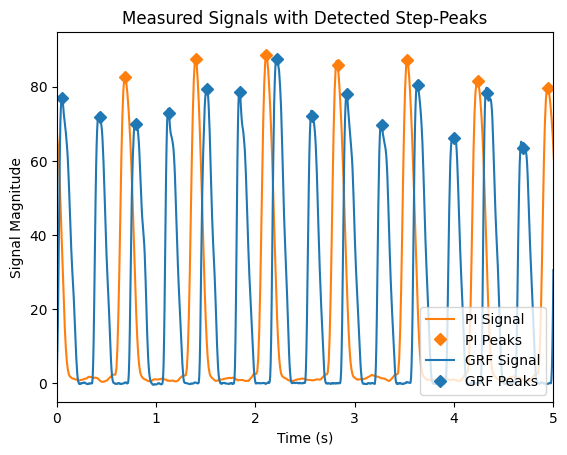

In [4]:
# Plot the signals and their peaks
plt.plot(timestamps_pi, arr_pi, color="C1", label="PI Signal")
plt.plot(pi_peak_times, arr_pi[peaks_pi_idx], marker="D", linestyle="None", color="C1", label="PI Peaks")

plt.plot(timestamps_ref, arr_ref, color="C0", label="GRF Signal")
plt.plot(ref_peak_times, arr_ref[peaks_ref_idx], marker="D", linestyle="None", color="C0", label="GRF Peaks")

plt.title("Measured Signals with Detected Step-Peaks")
plt.ylabel("Signal Magnitude")
plt.xlabel("Time (s)")
plt.xlim(0, 5)
plt.legend(loc="lower right")
plt.show()

## Nearest Advocate: Time-Delay Estimation

We now estimate the time delay between corresponding peaks:
- Search space (assumption of maximal possible time shift between the measurements): −10 s to +10 s  
- Resolution of the search space: 2000 1/s (~0.5 ms)  

**Output:**
- **Time delay**: the time shift that *minimizes the mean distance between matched (advocate) events of the two measurements*.

In [5]:
# define the search space
td_min, td_max = -10.0, 10.0  # minimal and maximal time-delta to be investigated
sps = 1000    # set the resolution of the search space (samples per seconds) to 1 ms.

# dist_max caps the maximal distance between any signal timestamp 
# and its nearest reference timestamp. Too low values decrease robustness 
# for noisy timestamps, too high values over-smooth the estimation's minima.
# Default None: Sets to 1/4 of the smaller median inter-event interval of the arrays 
# (1/4 * min(np.median(np.diff(arr_ref)), np.median(np.diff(arr_sig))))
# The default value with None is a good starting point
dist_max = None

# estimate the time-delay (the first execution needs longer as the module is compiled)
time_shifts = nearest_advocate.nearest_advocate(
    arr_ref=ref_peak_times,
    arr_sig=pi_peak_times,
    td_min=td_min,
    td_max=td_max,
    sps=sps,
    dist_max=dist_max
)

best_idx = np.argmin(time_shifts[:,1])
time_shift = time_shifts[best_idx, 0]
min_mean_dist = time_shifts[best_idx, 1]

print(f"Estimated a time delay of {time_shift:.4f} s with a minimal mean distance of {min_mean_dist:.6f} s")

Estimated a time delay of -0.1100 s with a minimal mean distance of 0.004762 s


### Characteristic Curve of the Nearest Advocate

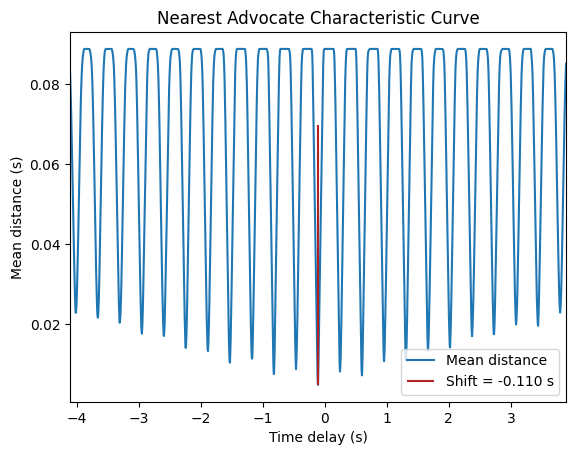

In [6]:
plt.plot(time_shifts[:,0], time_shifts[:,1], label="Mean distance")
plt.vlines(x=time_shift, ymin=min_mean_dist, ymax=np.mean(time_shifts[:,1]), color="firebrick", label=f"Shift = {time_shift:.3f} s")
plt.xlim(time_shift-4, time_shift+4)
plt.title("Nearest Advocate Characteristic Curve")
plt.xlabel("Time delay (s)")
plt.ylabel("Mean distance (s)")
plt.legend()
plt.show()

## Correcting the PI Signal

The estimated value represents time-delay of the signal array, here `arr_pi`. Therefore, the time-delay must be subtracted from the array's timestamps.

In [7]:
# correcting the signal data
pi_peak_times_corrected = pi_peak_times - time_shift
timestamps_pi_corrected = timestamps_pi - time_shift

### Visual Alignment Before & After Synchronization
We apply the estimated delay and compare alignment in a zoomed window.


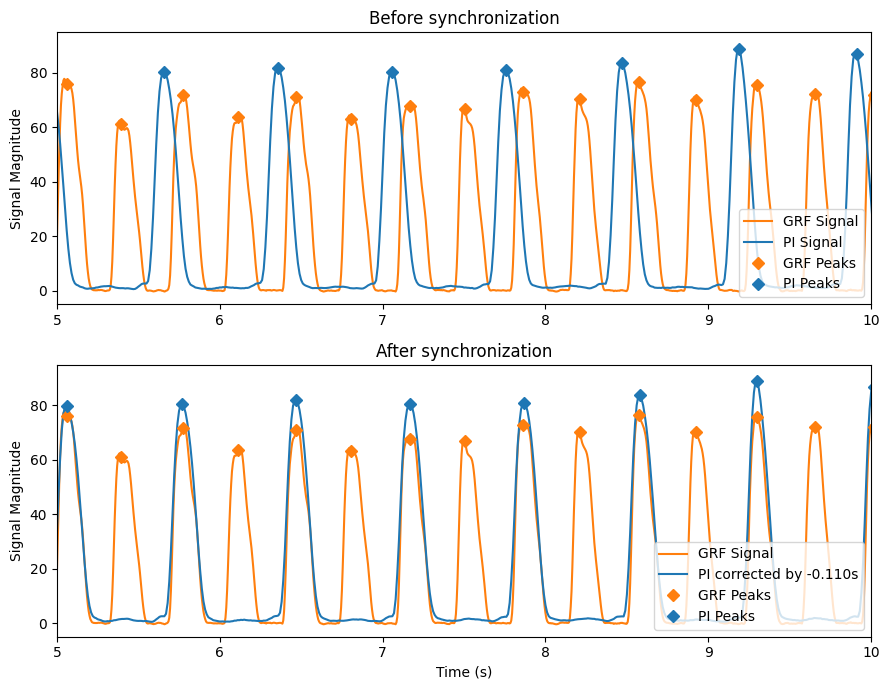

In [8]:
window = (5, 10)
fig, axs = plt.subplots(2, 1, figsize=(9, 7), sharey=True)

# Original
axs[0].plot(timestamps_ref, arr_ref, color="C1", label="GRF Signal")
axs[0].plot(timestamps_pi,  arr_pi, color="C0", label="PI Signal")
axs[0].plot(ref_peak_times, arr_ref[peaks_ref_idx], marker="D", linestyle="None", color="C1", label="GRF Peaks")
axs[0].plot(pi_peak_times, arr_pi[peaks_pi_idx], marker="D", linestyle="None", color="C0", label="PI Peaks")

axs[0].set_ylabel("Signal Magnitude")
axs[0].set_xlim(*window)
axs[0].set_title("Before synchronization")
axs[0].legend(loc="lower right")

# After Synchronization
axs[1].plot(timestamps_ref, arr_ref, color="C1", label="GRF Signal")
axs[1].plot(timestamps_pi_corrected,  arr_pi, color="C0", label=f"PI corrected by {time_shift:.3f}s")
axs[1].plot(ref_peak_times, arr_ref[peaks_ref_idx], marker="D", linestyle="None", color="C1", label="GRF Peaks")
axs[1].plot(pi_peak_times_corrected, arr_pi[peaks_pi_idx], marker="D", linestyle="None", color="C0", label="PI Peaks")
axs[1].set_xlim(*window)
axs[1].set_xlabel("Time (s)")
axs[1].set_ylabel("Signal Magnitude")
axs[1].set_title("After synchronization")
axs[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig("fig/step_sync.png", dpi=200)
plt.show()

### Assert there is no Time-Delay on the Corrected Timestamps

No or a neglectable time-delay.

In [9]:
time_shifts = nearest_advocate.nearest_advocate(
    arr_ref=ref_peak_times, arr_sig=pi_peak_times_corrected, 
    td_min=td_min, td_max=td_max, sps=sps, dist_max=dist_max, symmetric=False
)
time_shift, min_mean_dist = time_shifts[np.argmin(time_shifts[:,1])]
print(f"Estimated a time delay of {time_shift:.4f} s with a minimal mean distance of {min_mean_dist:.6f} s")

Estimated a time delay of 0.0000 s with a minimal mean distance of 0.004762 s


### Create a synchronized result file with both signals

In [10]:
# interpolate the signal to the reference timestamps
arr_pi_interpolated = np.interp(
    x=timestamps_ref, xp=timestamps_pi_corrected, fp=arr_pi, 
    left=np.nan, right=np.nan
)

df_gaits = pd.DataFrame(
    {
        "grf": arr_ref,
        "pi": arr_pi_interpolated
    }, 
    index=timestamps_ref
).dropna()  # drop all rows with NaNs
df_gaits.to_csv("gait_signals_synced.csv")  # save the gait signals to a file
df_gaits.head()

,grf,pi
0.110,60.499823,67.808374
0.115,57.709717,66.012355
0.120,54.335495,64.216336
0.125,50.563224,62.087990
0.130,46.724183,59.959644



---

## Advanced: Experimenting with Parameters of the Nearest Advocate algorithm

For the PI only half of the steps (only left) are available compared to the reference signal.
**If we know that peaks of our (left) PI signal are missing, it is highly suggested that this signal is passed as `arr_sig` and to set `symmetric=False`!**

We can learn a lot about the parameters, when we experiment on how to break the algorithm in the case of our many (even around 50%) missing peaks :)

1. We exchange the reference and signal array in NAd: `arr_ref=pi_peak_times, arr_sig=ref_peak_times` (we now also expect a negated time-delta)
2. We increase the `dist_max`. This parameter caps the maximal search distance between each peak to its nearest advocate reference peak.
3. We set `symmetric=True` (which just performs NAd twice with ref and signal arrays exchanged once and average the results)

Estimated a time delay of 0.8250 s with a minimal mean distance of 0.116500 s


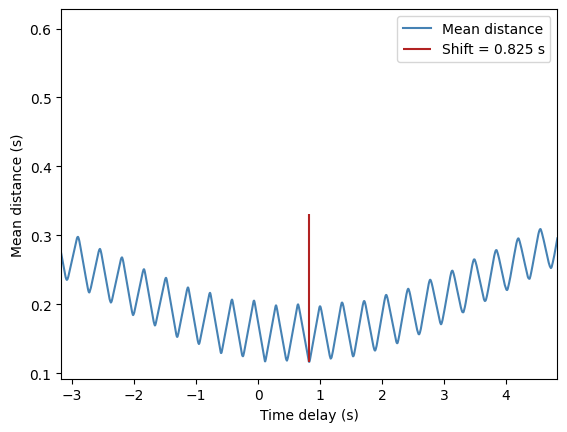

In [11]:
# Default None sets it to 1/4 of the smaller median inter-event interval of the arrays (here ~0.09 s)
# (1/4 * min(np.median(np.diff(arr_ref)), np.median(np.diff(arr_sig))))
dist_max = 1.5

# run the time-delay-estimation with the left PI sensor as reference and a high dist_max
time_shifts = nearest_advocate.nearest_advocate(
    arr_ref=pi_peak_times, arr_sig=ref_peak_times, 
    td_min=td_min, td_max=td_max, sps=sps, dist_max=dist_max, symmetric=True
)
time_shift, min_mean_dist = time_shifts[np.argmin(time_shifts[:,1])]
print(f"Estimated a time delay of {time_shift:.4f} s with a minimal mean distance of {min_mean_dist:.6f} s")

plt.plot(time_shifts[:,0], time_shifts[:,1], color="steelblue", label="Mean distance")
plt.vlines(x=time_shift, ymin=min_mean_dist, ymax=np.mean(time_shifts[:,1]), color="firebrick", label=f"Shift = {time_shift:.3f} s")
plt.xlim(time_shift-4, time_shift+4)
plt.xlabel("Time delay (s)")
plt.ylabel("Mean distance (s)")
plt.legend()
plt.show()

We could see, that we were successful in crashing the algorithm :)

However, when we just set `dist_max` to the default or a value smaller than the inter-step interval and keep the swiched input arrays, the Nearest Advocate algorithm still yields the correct time-delay.

Found an optimum at a time-delay of -0.1100 s with a minimal mean distance of 0.008825 s


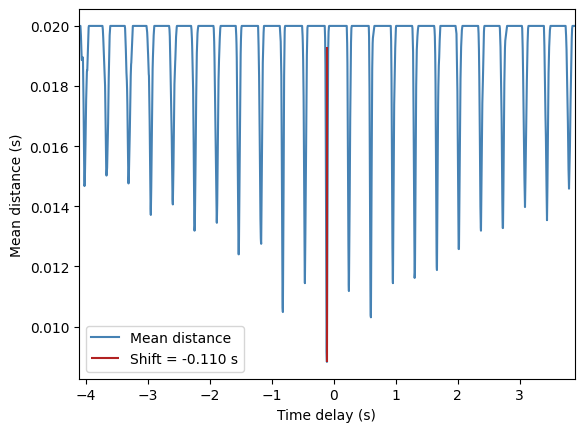

In [12]:
# Default None: 1/4 of the smaller median inter-event interval of the arrays 
# (1/4 * min(np.median(np.diff(arr_ref)), np.median(np.diff(arr_sig))))
dist_max = 0.02

# run the time-delay-estimation with the left PI sensor as reference and a high dist_max
time_shifts = nearest_advocate.nearest_advocate(
    arr_ref=ref_peak_times, arr_sig=pi_peak_times, 
    td_min=td_min, td_max=td_max, sps=sps, dist_max=dist_max, symmetric=True
)
time_shift, min_mean_dist = time_shifts[np.argmin(time_shifts[:,1])]
print(f"Found an optimum at a time-delay of {time_shift:.4f} s with a minimal mean distance of {min_mean_dist:.6f} s")

plt.plot(time_shifts[:,0], time_shifts[:,1], color="steelblue", label="Mean distance")
plt.vlines(x=time_shift, ymin=min_mean_dist, ymax=np.mean(time_shifts[:,1]), color="firebrick", label=f"Shift = {time_shift:.3f} s")
plt.xlim(time_shift-4, time_shift+4)
plt.xlabel("Time delay (s)")
plt.ylabel("Mean distance (s)")
plt.legend()
plt.show()